<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:97: SyntaxWarning: invalid escape sequence '\m'
C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_11516\1504459500.py:86: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_xlabel('Concentración $PM_{2.5}$ ($\mu g/m^3$)')
C:\Users\CommodorePlus\AppData\Local\Temp\ipykernel_11516\1504459500.py:97: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_xlabel('Concentración $PM_{10}$ ($\mu g/m^3$)')


INICIANDO SCRIPT 3 CORREGIDO: FEATURE ENGINEERING + NOM
Aplicando Promedios Móviles Normativos (NOM-020 y NOM-172)...
Generando rezagos temporales (Time-Lags)...
✅ ¡Dataset Predictivo Corregido y Guardado! Total Filas: 413,441

INICIANDO SCRIPT 4: GRÁFICAS DE ETAPA 3
Generando Gráficos de Ajuste Físico-Estadístico...


d:\Codingggg\Notas\Multivariados\MA2003B_Eq1\.venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6986: RuntimeWarning: divide by zero encountered in log
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)


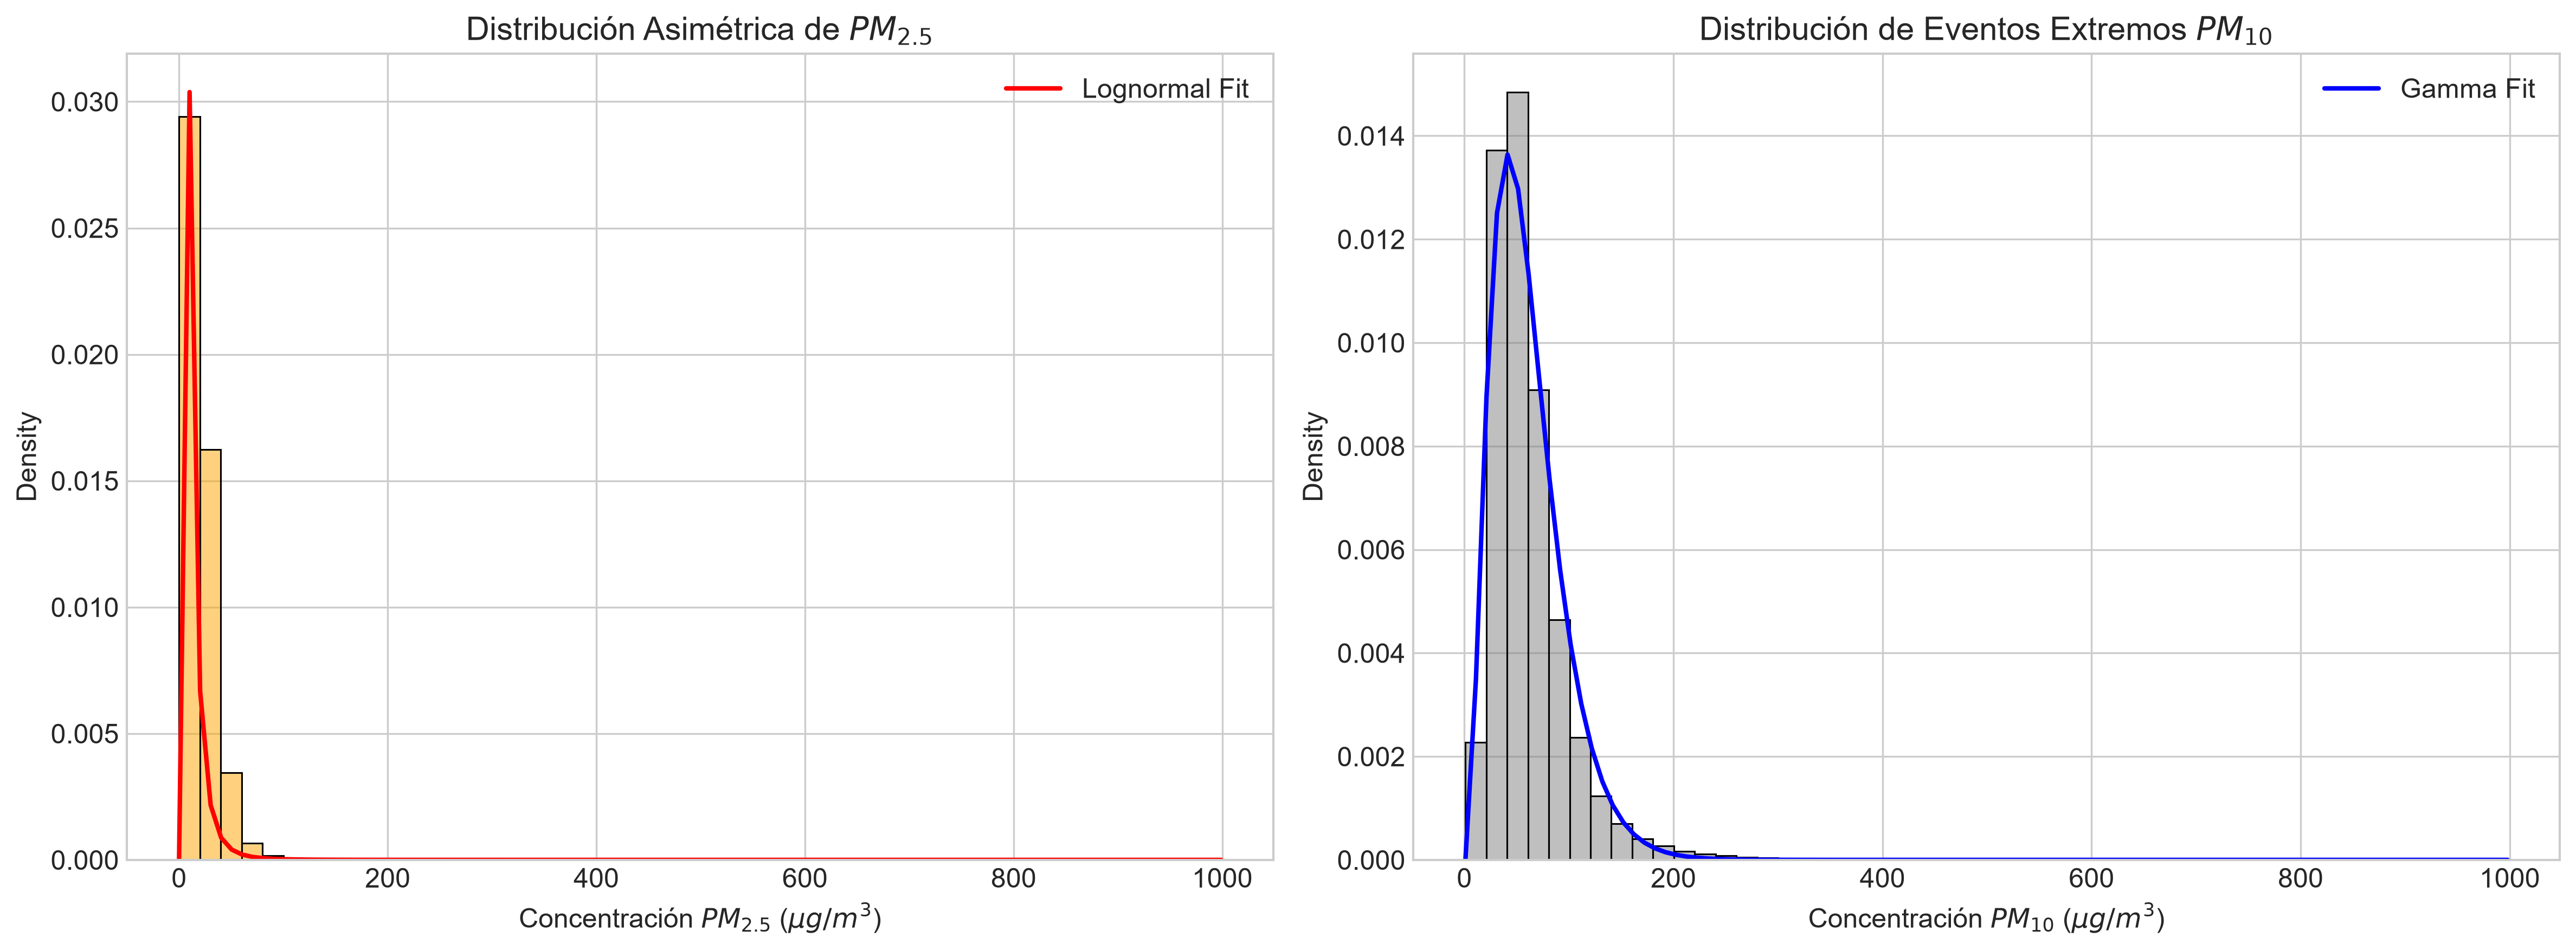

Generando Análisis de Correlación Cruzada (CCF)...


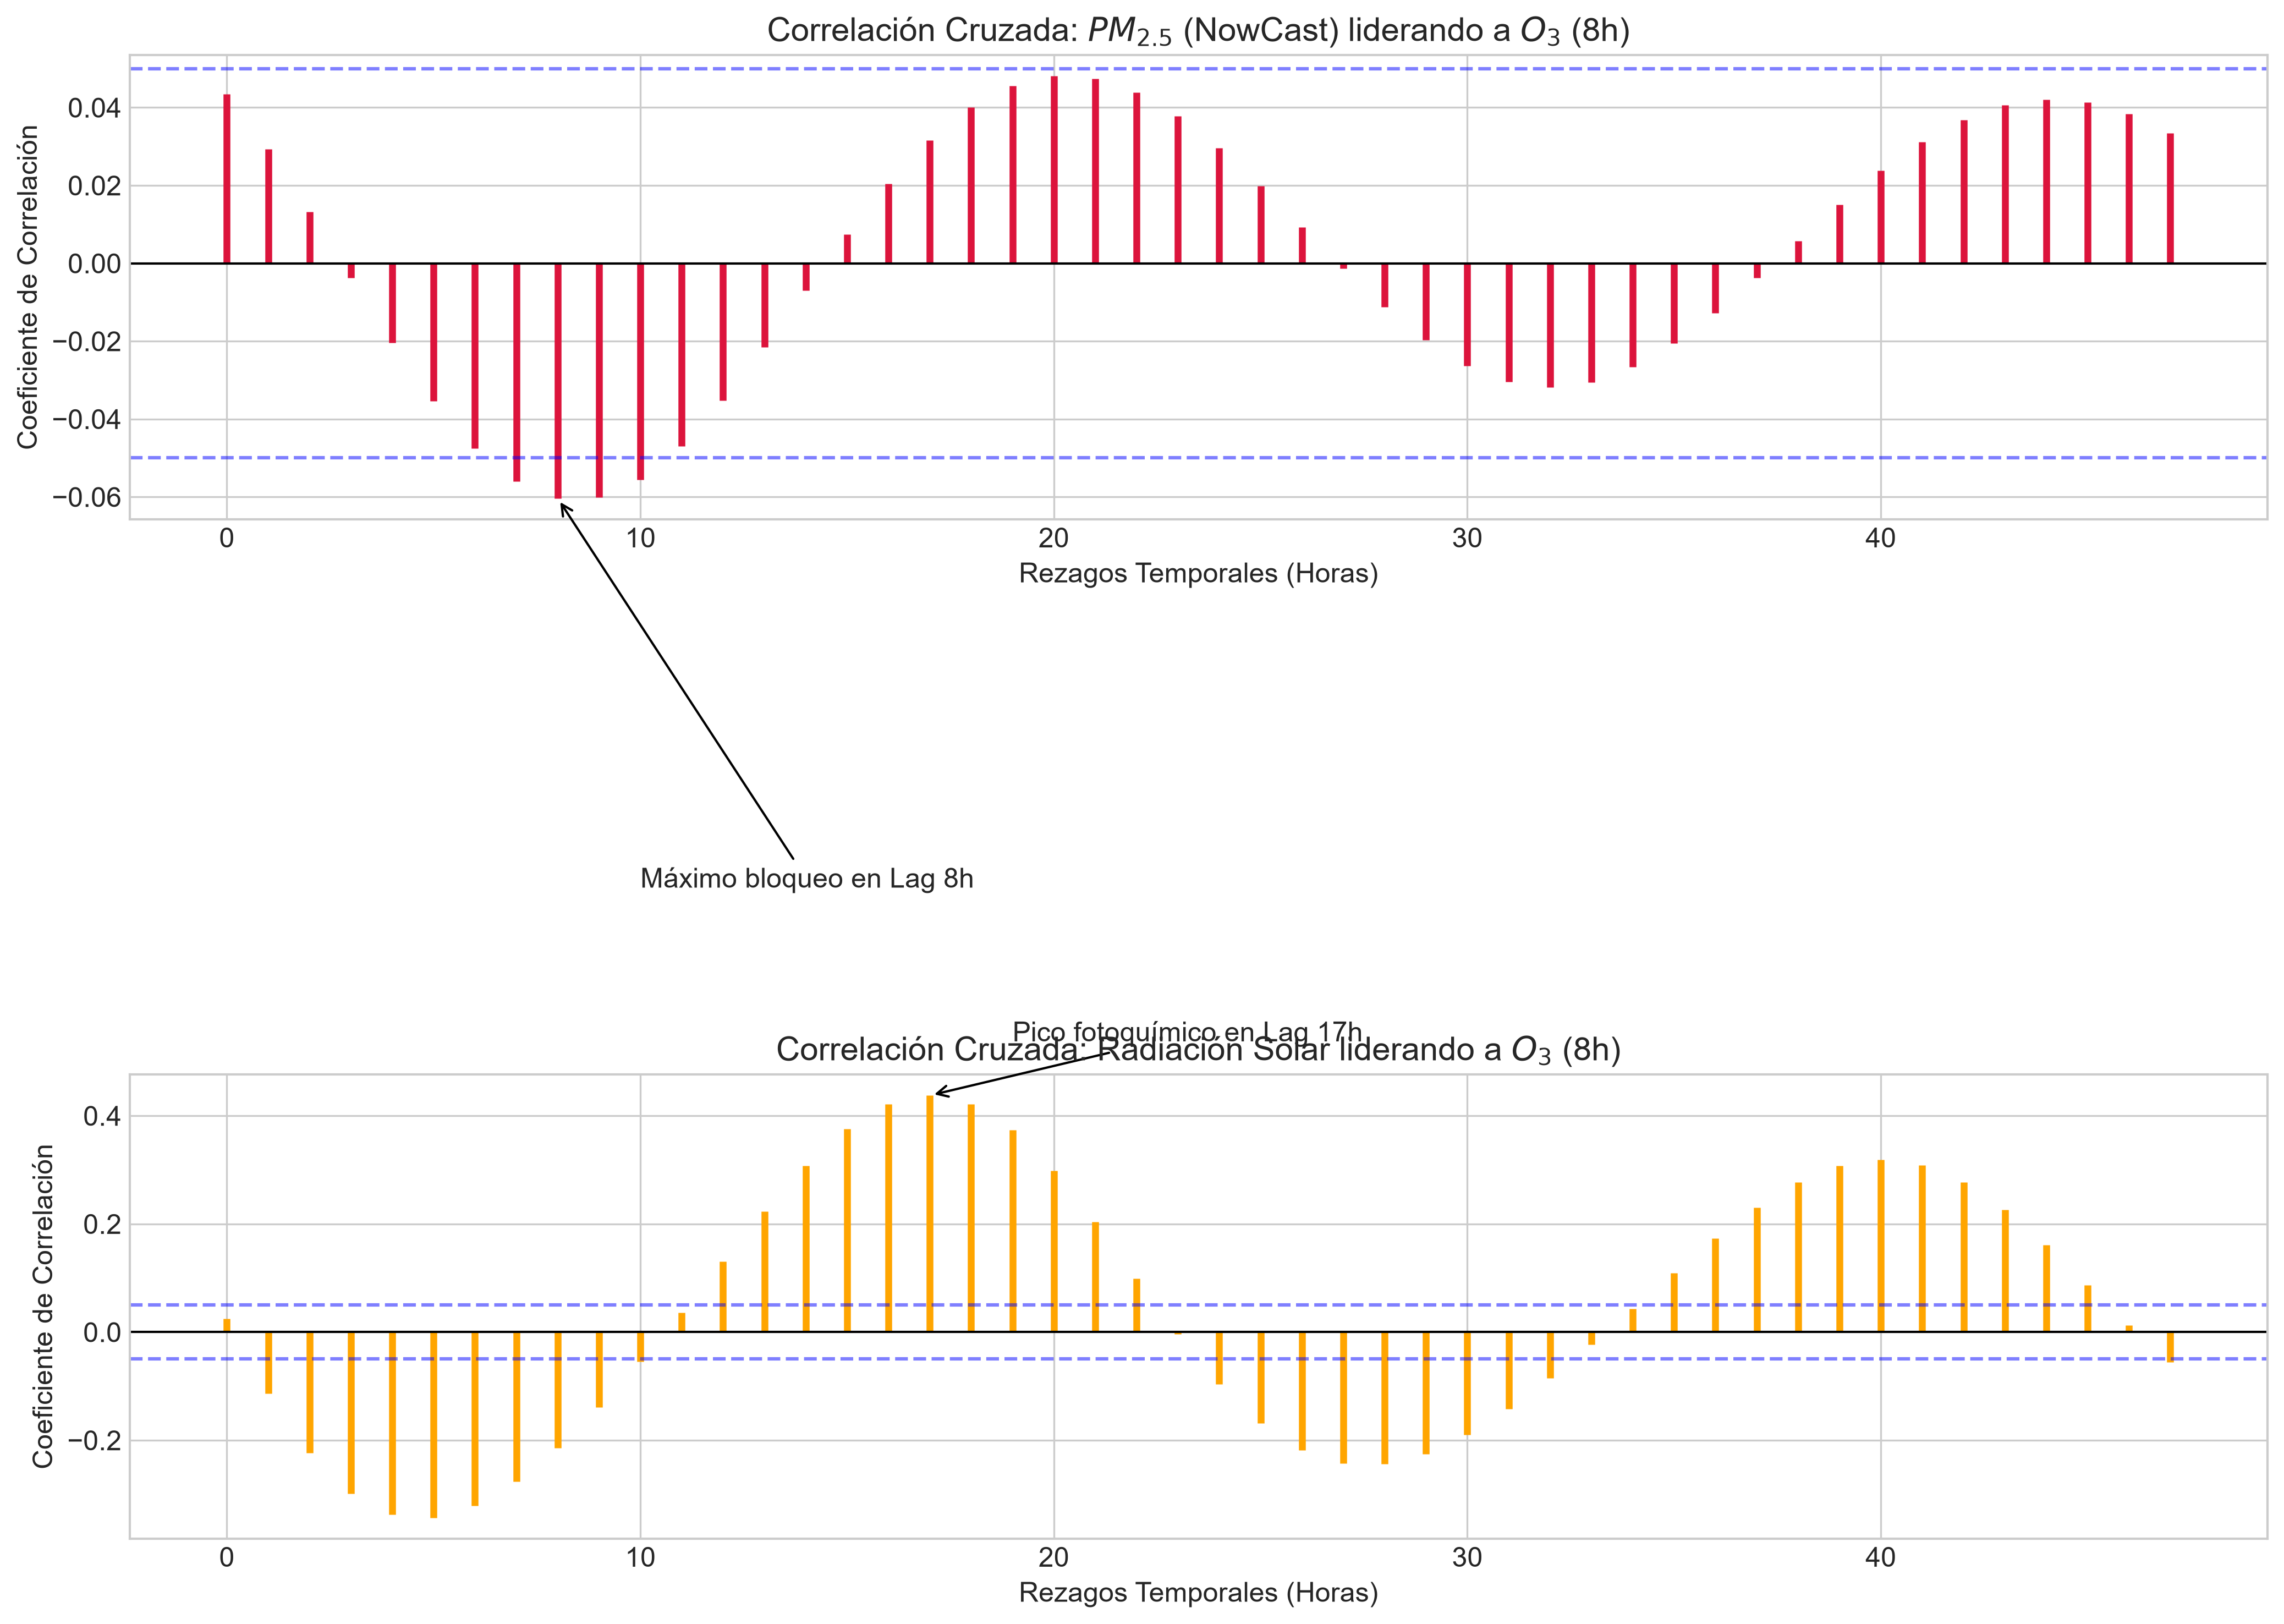


🚀 LISTO. Revisa las imágenes y dime qué valores de 'Lag' aparecieron en las gráficas.


In [3]:
import pandas as pd
import numpy as np
import os
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf

# Configuración visual pro
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 300})

print("=======================================================")
print("INICIANDO SCRIPT 3 CORREGIDO: FEATURE ENGINEERING + NOM")
print("=======================================================")

# 1. CARGAMOS AHORA SÍ TODAS LAS VARIABLES (INCLUYENDO PM)
variables = ['O3', 'NOX', 'SR', 'TOUT', 'WSR', 'WDR', 'PM10', 'PM2.5']
dfs = []

for var in variables:
    ruta = f"data/processed/variables/{var}_clean.parquet"
    if os.path.exists(ruta):
        df_var = pd.read_parquet(ruta)
        dfs.append(df_var)
    else:
        print(f"⚠️ Advertencia: No se encontró {ruta}")

# 2. INNER JOIN Y ORDEN TEMPORAL
df_ml = reduce(lambda left, right: pd.merge(left, right, on=['Date', 'Estacion'], how='inner'), dfs)
df_ml.sort_values(by=['Estacion', 'Date'], inplace=True)
df_ml.reset_index(drop=True, inplace=True)

# 3. APLICACIÓN DE LA NORMATIVA (Promedios móviles antes del dropna)
print("Aplicando Promedios Móviles Normativos (NOM-020 y NOM-172)...")
estaciones = df_ml.groupby('Estacion')

# Ozono a 8 horas (NOM-020)
df_ml['O3_8h'] = estaciones['O3'].rolling(window=8, min_periods=6).mean().reset_index(level=0, drop=True)
# Partículas a 12 horas (Aproximación NOM-172 NowCast)
df_ml['PM2.5_12h'] = estaciones['PM2.5'].rolling(window=12, min_periods=9).mean().reset_index(level=0, drop=True)
df_ml['PM10_12h'] = estaciones['PM10'].rolling(window=12, min_periods=9).mean().reset_index(level=0, drop=True)

# 4. TRANSFORMACIÓN VECTORIAL DEL VIENTO (U, V)
radianes = df_ml['WDR'] * (np.pi / 180)
df_ml['U_Wind'] = -df_ml['WSR'] * np.sin(radianes)
df_ml['V_Wind'] = -df_ml['WSR'] * np.cos(radianes)
df_ml.drop(columns=['WDR', 'WSR'], inplace=True)

# 5. TIME-LAGS (Generando el "pasado")
print("Generando rezagos temporales (Time-Lags)...")
for lag in [1, 2, 3, 4]:
    df_ml[f'NOX_lag_{lag}'] = estaciones['NOX'].shift(lag)
    df_ml[f'SR_lag_{lag}'] = estaciones['SR'].shift(lag)

for lag in [2, 4]:
    df_ml[f'TOUT_lag_{lag}'] = estaciones['TOUT'].shift(lag)

for lag in [1, 2]:
    df_ml[f'U_Wind_lag_{lag}'] = estaciones['U_Wind'].shift(lag)
    df_ml[f'V_Wind_lag_{lag}'] = estaciones['V_Wind'].shift(lag)

# Limpieza Final
df_ml_final = df_ml.dropna().reset_index(drop=True)
ruta_final = "data/ml_ready/dataset_ozono_predictivo.parquet"
df_ml_final.to_parquet(ruta_final, index=False)
print(f"✅ ¡Dataset Predictivo Corregido y Guardado! Total Filas: {df_ml_final.shape[0]:,}")

print("\n=======================================================")
print("INICIANDO SCRIPT 4: GRÁFICAS DE ETAPA 3")
print("=======================================================")

# --- TÉCNICA 1: INTERDEPENDENCIA (AJUSTE DE DISTRIBUCIONES) ---
print("Generando Gráficos de Ajuste Físico-Estadístico...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ajuste Lognormal para PM2.5
shape_log, loc_log, scale_log = stats.lognorm.fit(df_ml_final['PM2.5'])
x_pm25 = np.linspace(df_ml_final['PM2.5'].min(), df_ml_final['PM2.5'].max(), 100)
pdf_lognorm = stats.lognorm.pdf(x_pm25, shape_log, loc=loc_log, scale=scale_log)

sns.histplot(df_ml_final['PM2.5'], bins=50, stat='density', alpha=0.5, color='orange', ax=axes[0])
axes[0].plot(x_pm25, pdf_lognorm, 'r-', lw=2, label=f'Lognormal Fit')
axes[0].set_title('Distribución Asimétrica de $PM_{2.5}$')
axes[0].set_xlabel('Concentración $PM_{2.5}$ ($\mu g/m^3$)')
axes[0].legend()

# Ajuste Gamma para PM10
shape_gam, loc_gam, scale_gam = stats.gamma.fit(df_ml_final['PM10'])
x_pm10 = np.linspace(df_ml_final['PM10'].min(), df_ml_final['PM10'].max(), 100)
pdf_gamma = stats.gamma.pdf(x_pm10, shape_gam, loc=loc_gam, scale=scale_gam)

sns.histplot(df_ml_final['PM10'], bins=50, stat='density', alpha=0.5, color='gray', ax=axes[1])
axes[1].plot(x_pm10, pdf_gamma, 'b-', lw=2, label=f'Gamma Fit')
axes[1].set_title('Distribución de Eventos Extremos $PM_{10}$')
axes[1].set_xlabel('Concentración $PM_{10}$ ($\mu g/m^3$)')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/Etapa3_01_Distribuciones.png')
plt.show()

# --- TÉCNICA 2: DEPENDENCIA (CORRELACIÓN CRUZADA) ---
print("Generando Análisis de Correlación Cruzada (CCF)...")
lags_to_plot = 48 # Horizonte de 48 horas

# ccf mide cómo la primera variable lidera a la segunda.
ccf_pm25_o3 = ccf(df_ml_final['PM2.5_12h'], df_ml_final['O3_8h'], adjusted=False)[:lags_to_plot]
ccf_sr_o3 = ccf(df_ml_final['SR'], df_ml_final['O3_8h'], adjusted=False)[:lags_to_plot]
lags = np.arange(0, lags_to_plot)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# CCF: PM2.5 vs O3 (Buscando el efecto de bloqueo)
axes[0].vlines(lags, [0], ccf_pm25_o3, color='crimson', lw=3)
axes[0].axhline(0, color='black', lw=1)
axes[0].axhline(0.05, color='blue', linestyle='--', alpha=0.5)
axes[0].axhline(-0.05, color='blue', linestyle='--', alpha=0.5)
axes[0].set_title('Correlación Cruzada: $PM_{2.5}$ (NowCast) liderando a $O_3$ (8h)')
axes[0].set_ylabel('Coeficiente de Correlación')
axes[0].set_xlabel('Rezagos Temporales (Horas)')

min_lag_pm = np.argmin(ccf_pm25_o3)
axes[0].annotate(f'Máximo bloqueo en Lag {min_lag_pm}h', 
                 xy=(min_lag_pm, ccf_pm25_o3[min_lag_pm]), 
                 xytext=(min_lag_pm+2, ccf_pm25_o3[min_lag_pm]-0.1),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

# CCF: SR vs O3 (Buscando el pico fotoquímico)
axes[1].vlines(lags, [0], ccf_sr_o3, color='orange', lw=3)
axes[1].axhline(0, color='black', lw=1)
axes[1].axhline(0.05, color='blue', linestyle='--', alpha=0.5)
axes[1].axhline(-0.05, color='blue', linestyle='--', alpha=0.5)
axes[1].set_title('Correlación Cruzada: Radiación Solar liderando a $O_3$ (8h)')
axes[1].set_ylabel('Coeficiente de Correlación')
axes[1].set_xlabel('Rezagos Temporales (Horas)')

max_lag_sr = np.argmax(ccf_sr_o3)
axes[1].annotate(f'Pico fotoquímico en Lag {max_lag_sr}h', 
                 xy=(max_lag_sr, ccf_sr_o3[max_lag_sr]), 
                 xytext=(max_lag_sr+2, ccf_sr_o3[max_lag_sr]+0.1),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.savefig('results/figures/Etapa3_02_CCF.png')
plt.show()

print("\n🚀 LISTO. Revisa las imágenes y dime qué valores de 'Lag' aparecieron en las gráficas.")